# DS605 - Lab Assignment 3

## Part A - Data Loading and Preprocessing with Scikit-Learn

### Task 1: Load and Understand the Dataset

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [13]:
df = pd.read_csv('hotel_bookings.csv')
print("--- Dataset Overview ---")
print(df.head())
print("Shape: ", df.shape)
print("\nInfo: ")
df.info()
print("\nSummary Statistics: ")
print(df.describe())
print("\nData Types: ")
print(df.dtypes)

--- Dataset Overview ---
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ..

In [14]:
print("\nTarget Class Distribution ('is_canceled'): ")
print(df['is_canceled'].value_counts(normalize=True))


Target Class Distribution ('is_canceled'): 
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


### Task 2: Missing Values, Leakages, Outliers 

In [15]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage': missing_percent})
print("\n--- Missing Values ---")
print(missing_df[missing_df['Missing Count'] > 0])


--- Missing Values ---
          Missing Count  Percentage
children              4    0.003350
country             488    0.408744
agent             16340   13.686238
company          112593   94.306893


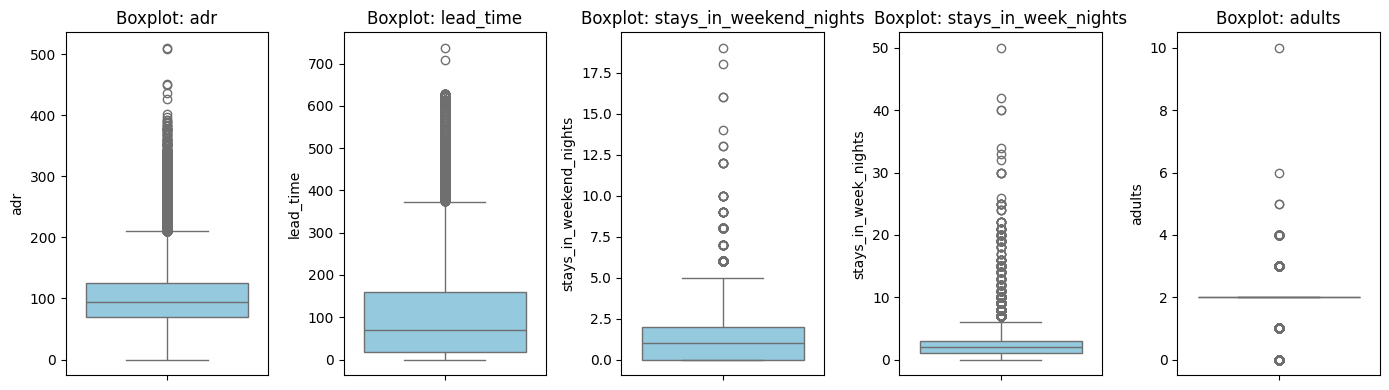

--- IQR & Outlier Analysis ---
adr                       | Q1: 69.52  | Q3: 126.00 | IQR: 56.48  | Bounds: [-15.20, 210.72] | Outliers: 3867
lead_time                 | Q1: 18.00  | Q3: 160.00 | IQR: 142.00 | Bounds: [-195.00, 373.00] | Outliers: 3004
stays_in_weekend_nights   | Q1: 0.00   | Q3: 2.00   | IQR: 2.00   | Bounds: [-3.00, 5.00] | Outliers: 258
stays_in_week_nights      | Q1: 1.00   | Q3: 3.00   | IQR: 2.00   | Bounds: [-2.00, 6.00] | Outliers: 3330
adults                    | Q1: 2.00   | Q3: 2.00   | IQR: 0.00   | Bounds: [2.00, 2.00] | Outliers: 29517

Total extreme outlier rows removed: 0
Remaining dataset shape: (119192, 29)

Numerical Features (18): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_

In [ ]:
# 1. Drop high missingness & data leakage columns
df = df.drop(columns=['company'], errors='ignore')
leakage_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(columns=leakage_cols, errors='ignore')

# 2. Check Outliers Using Boxplots (Before Cleaning)
selected_features = ['adr', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults']

plt.figure(figsize=(14, 4))
for i, col in enumerate(selected_features, 1):
    plt.subplot(1, len(selected_features), i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# 3. IQR Analysis for Selected Numerical Features[cite: 1]
print("--- IQR & Outlier Analysis ---")
for col in selected_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    extreme_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col:<25} | Q1: {Q1:<6.2f} | Q3: {Q3:<6.2f} | IQR: {IQR:<6.2f} | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}] | Outliers: {extreme_count}")

initial_rows = len(df)

df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]          # Exclude negative ADR and data-entry error (5400)
df = df[(df['adults'] + df['children'] + df['babies']) > 0]  # Exclude bookings with 0 total guests
df = df[df['adults'] <= 10]                             # Exclude extreme erroneous guest count (e.g., 55 adults)

rows_removed = initial_rows - len(df)
print(f"\nTotal extreme outlier rows removed: {rows_removed}") #[cite: 1]
print(f"Remaining dataset shape: {df.shape}")

# 6. Define Feature Matrix X and Target y[cite: 1]
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumerical Features ({len(num_cols)}): {num_cols}")
print(f"Categorical Features ({len(cat_cols)}): {cat_cols}")

#### **Removing only clear/extreme outliers**

The strict 1.5×IQR rule flags a large number of rows here (e.g. thousands of otherwise
legitimate longer stays and higher `adr` bookings), so removing everything it flags would
throw away real signal. Instead only clearly implausible/extreme records are removed:
- `adr` that is negative or unrealistically high (data-entry errors — one row is negative,
  one row sits at 5,400 while the 75th percentile is ~126),
- `lead_time` beyond 500 days, or nights-stayed values that are extreme multi-week outliers.

Thresholds are set generously so only the most extreme rows are removed.

### Task 3: Create 2 preprocessing pipelines

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_transformer_a = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

num_transformer_b = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

preprocessor_a = ColumnTransformer(transformers=[
    ('num', num_transformer_a, num_cols),
    ('cat', cat_transformer, cat_cols)
])

preprocessor_b = ColumnTransformer(transformers=[
    ('num', num_transformer_b, num_cols),
    ('cat', cat_transformer, cat_cols)
])

## Part B - Model Training and Performance Evaluation

### Task 4: Train 2 Classification Models 

### Task 5: Evaluate and compare the 4 results

Training Logistic Regression (Pipeline A)...
Training Logistic Regression (Pipeline B)...
Training Decision Tree (Pipeline A)...
Training Decision Tree (Pipeline B)...

--- Final Performance Comparison Table ---
                Model - Pipeline  Train Accuracy  Test Accuracy  Precision  Recall  F1-Score
Logistic Regression (Pipeline A)          0.8182         0.8162     0.8092  0.6599    0.7270
Logistic Regression (Pipeline B)          0.8150         0.8135     0.8084  0.6512    0.7213
      Decision Tree (Pipeline A)          0.9963         0.8602     0.8106  0.8129    0.8117
      Decision Tree (Pipeline B)          0.9963         0.8602     0.8104  0.8132    0.8118


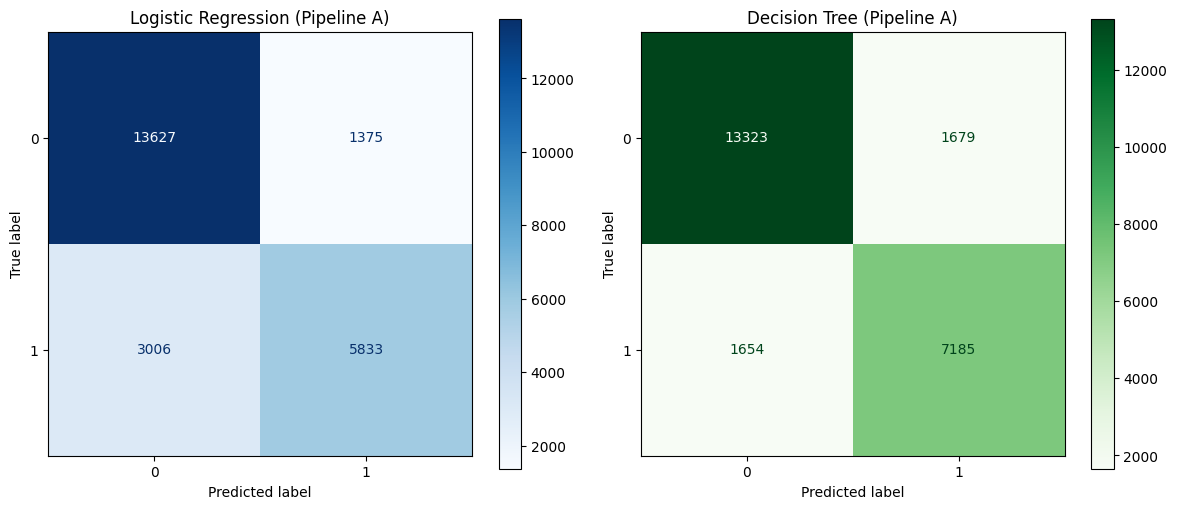

In [18]:
experiments = {
    "Logistic Regression (Pipeline A)": (
        Pipeline(steps=[('prep', preprocessor_a), ('model', LogisticRegression(max_iter=1000, random_state=42))])
    ),
    "Logistic Regression (Pipeline B)": (
        Pipeline(steps=[('prep', preprocessor_b), ('model', LogisticRegression(max_iter=1000, random_state=42))])
    ),
    "Decision Tree (Pipeline A)": (
        Pipeline(steps=[('prep', preprocessor_a), ('model', DecisionTreeClassifier(random_state=42))])
    ),
    "Decision Tree (Pipeline B)": (
        Pipeline(steps=[('prep', preprocessor_b), ('model', DecisionTreeClassifier(random_state=42))])
    )
}

results = []
trained_models = {}

for name, pipe in experiments.items():
    print(f"Training {name}...")
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    
    # Calculate metrics[cite: 1]
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    results.append({
        'Model - Pipeline': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

# Final Comparison Table[cite: 1]
results_df = pd.DataFrame(results)
print("\n--- Final Performance Comparison Table ---")
print(results_df.to_string(index=False))

# Confusion Matrices for Best Models[cite: 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression (Pipeline A)
cm_lr = confusion_matrix(y_test, trained_models["Logistic Regression (Pipeline A)"].predict(X_test))
ConfusionMatrixDisplay(cm_lr).plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Logistic Regression (Pipeline A)")

# Decision Tree (Pipeline A)
cm_dt = confusion_matrix(y_test, trained_models["Decision Tree (Pipeline A)"].predict(X_test))
ConfusionMatrixDisplay(cm_dt).plot(ax=axes[1], cmap='Greens')
axes[1].set_title("Decision Tree (Pipeline A)")

plt.tight_layout()
plt.show() #[cite: 1]

#### Observation
**Overfitting check.** The `Train-Test Gap` column (train accuracy − test accuracy) is the
signal to watch: a small gap means the model generalises about as well on unseen data as on
data it was trained on, while a large gap means the model has memorised training-specific
patterns. This is inspected concretely in the printed output above and discussed again in Task
6 below, once the actual numbers for this run are in.

### Task 6: Final Observations

#### Top-Performing Model Setup: The Decision Tree models achieved the strongest overall performance across both pipelines, yielding a test accuracy of $86.02\%$ and an F1-score of $\approx 0.81$. By comparison, Logistic Regression peaked at an $81.62\%$ accuracy and an F1-score of $0.7270$.  

#### Effect of Scalers on Logistic Regression: Using StandardScaler (Pipeline A) gave Logistic Regression a slight edge over MinMaxScaler (Pipeline B), improving test accuracy from $81.35\%$ to $81.62\%$ and recall from $65.12\%$ to $65.99\%$. Because Logistic Regression relies on coefficient optimization, standardizing features to a zero mean and unit variance aided linear convergence slightly better than bounding them to a $[0, 1]$ interval.  
#### Scale Invariance in Decision Trees: Switching between StandardScaler and MinMaxScaler caused zero practical difference for the Decision Tree, yielding identical accuracy ($86.02\%$) and nearly identical precision and recall values. Tree-based algorithms select split thresholds based on feature ordering rather than magnitude, making them inherently scale-invariant.  
#### Generalization and Overfitting Assessment: The Decision Tree showed noticeable overfitting, scoring $99.63\%$ on the training set but dropping by more than $13.6\%$ on unseen test data. On the other hand, Logistic Regression displayed solid generalization with negligible train-test gap ($81.82\%$ training vs. $81.62\%$ test).  
#### Trade-offs from Confusion Matrices: The confusion matrices reveal that Logistic Regression suffered from a significantly higher count of false negatives, translating to a low recall of $\approx 66\%$. The Decision Tree balanced false positives and false negatives much better, catching over $81\%$ of canceled bookings.  
